## **seaborn**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

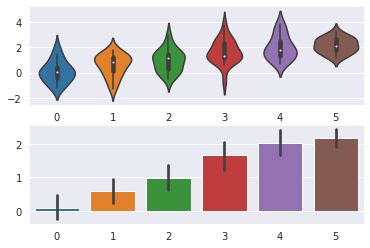

In [ ]:
data = np.random.normal(size=(20, 6)) + np.arange(6) / 2

with sns.axes_style("darkgrid"):
    plt.subplot(211)
    sns.violinplot(data=data)
    plt.subplot(212)
    sns.barplot(data=data)
    plt.show()

## 2. Plot Aesthetics

2.1. Style Management

In [ ]:
sns.axes_style()

# 배경 스타일을 darkgrid로 적용하고 투명도를 0.9로
sns.set_style("darkgrid", {"axes.facecolor": "0.9"})

# 혹은 간단하게 darkgrid만 적용하고 싶다면,
sns.set(style="darkgrid")

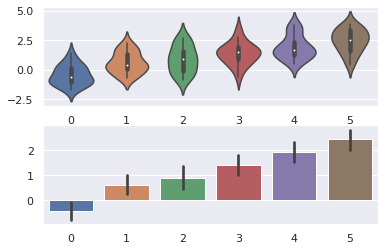

In [ ]:
data = np.random.normal(size=(20, 6)) + np.arange(6) / 2

with sns.axes_style("darkgrid"):
    plt.subplot(211)
    sns.violinplot(data=data)
    plt.subplot(212)
    sns.barplot(data=data)
    plt.show()

2.2. Color Management

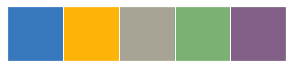

In [ ]:
colors = ["windows blue", "amber", "greyish", "faded green", "dusty purple"]
sns.palplot(sns.xkcd_palette(colors))

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


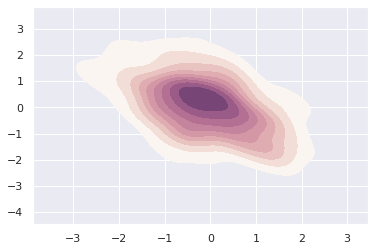

In [ ]:
cubehelix_palette = sns.cubehelix_palette(8, start=2, rot=0.2, dark=0, light=.95,
                                          reverse=True, as_cmap=True)
x, y = np.random.multivariate_normal([0, 0], [[1, -0.5], [-0.5, 1]], size=300).T
cmap = sns.cubehelix_palette(dark=0.3, light=1, as_cmap=True)
sns.kdeplot(x, y, cmap=cmap, shade=True)

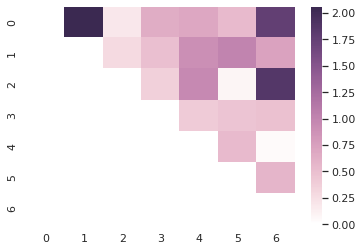

In [ ]:
arr = np.array(np.abs(np.random.randn(49))).reshape((7,7))
mask = np.tril_indices_from(arr)
arr[mask] = False

palette = sns.cubehelix_palette(n_colors=7, start=0, rot=0.3,
                                light=1.0, dark=0.2, reverse=False, as_cmap=True)
sns.heatmap(arr, cmap=palette)
plt.show()

#3. Plotting Functions

3.1. Visualizing statistical relationships

In [ ]:
tips = sns.load_dataset('tips')
tips.head(6)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4


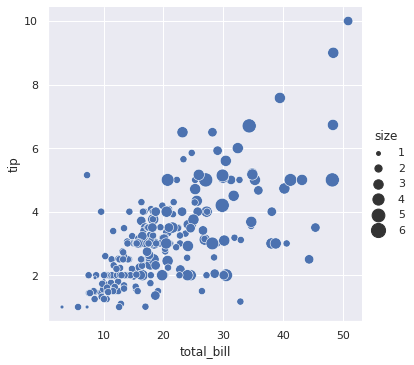

In [ ]:
# 3.1.1. Scatter plot
sns.relplot(x="total_bill", y="tip", size="size", sizes=(15, 200), data=tips)

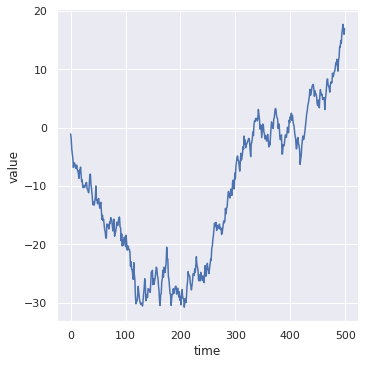

In [ ]:
# 3.1.2. Line plot
df = pd.DataFrame(dict(time=np.arange(500),
                     value=np.random.randn(500).cumsum()))
sns.relplot(x="time", y="value", kind="line", data=df)

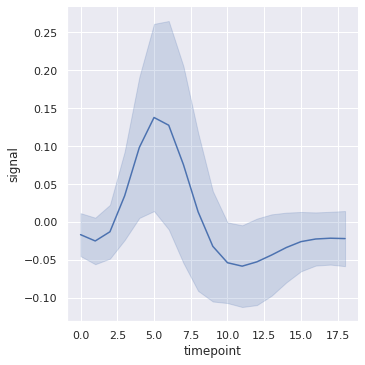

In [ ]:
# seaborn이 제공하는 데이터 프레임 불러오기
fmri = sns.load_dataset("fmri")

sns.relplot(x="timepoint", y="signal", kind="line", data=fmri, ci="sd")

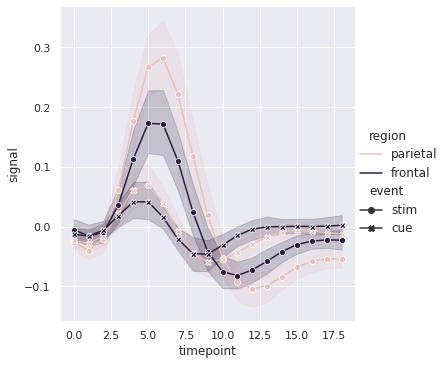

In [ ]:
pal = sns.cubehelix_palette(light=0.8, n_colors=2)
sns.relplot(x="timepoint", y="signal", hue="region", style="event",
            palette=pal, dashes=False, markers=True, kind="line", data=fmri)

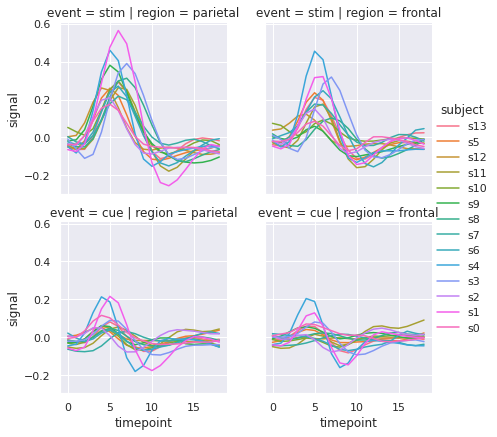

In [ ]:
sns.relplot(x="timepoint", y="signal", hue="subject", col="region",
            row="event", height=3, kind="line", estimator=None, data=fmri)

3.2. Plotting with categorical data

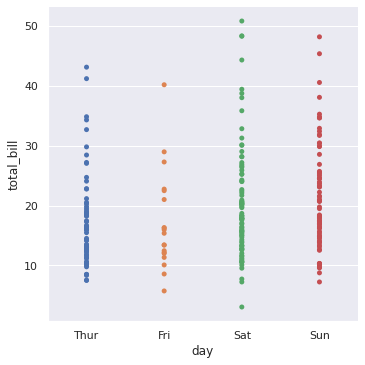

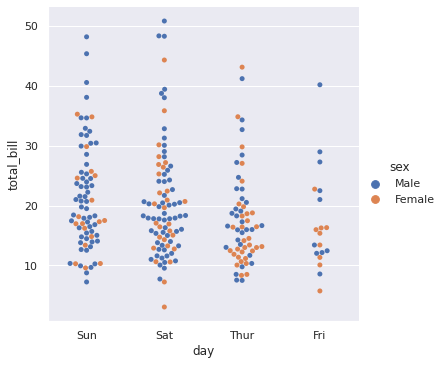

In [ ]:
# 3.2.1. Categorical Scatterplots: strip, swarm

sns.catplot(x="day", y="total_bill", jitter=False, data=tips)
sns.catplot(x="day", y="total_bill", hue="sex", kind="swarm",
            order=["Sun", "Sat", "Thur", "Fri"], data=tips)

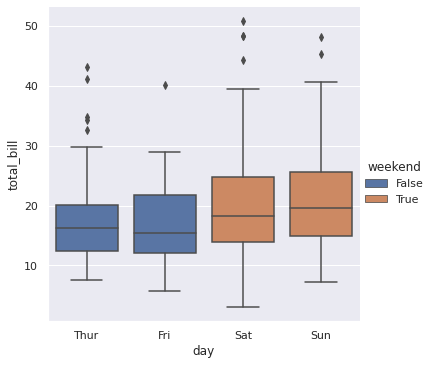

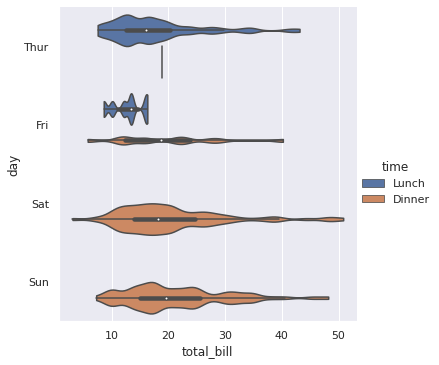

In [ ]:
# 3.2.2. Distribution of observations within categories: box, violin

tips["weekend"] = tips["day"].isin(["Sat", "Sun"])

sns.catplot(x="day", y="total_bill", hue="weekend", orient='v',
            kind="box", dodge=False, data=tips, legend=True)
sns.catplot(x="total_bill", y="day", hue="time",
            kind="violin", bw=.15, cut=0, data=tips)

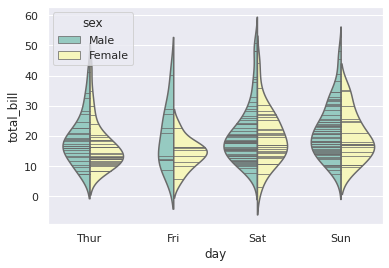

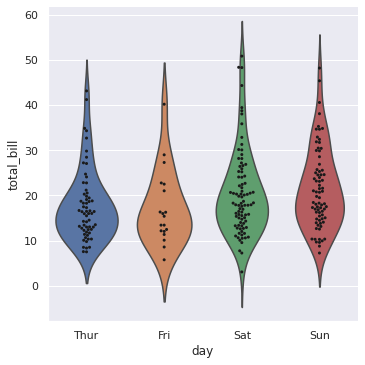

In [ ]:
# Inner Stick 사용
sns.violinplot(x="day", y="total_bill", hue="sex", data=tips,
               split=True, inner="stick", palette="Set3")

# 결합: 분포와 실제 데이터까지 한번에 보여주는 방법
g = sns.catplot(x="day", y="total_bill", kind="violin", inner=None, data=tips)
sns.swarmplot(x="day", y="total_bill", color="k", size=3, data=tips, ax=g.ax)

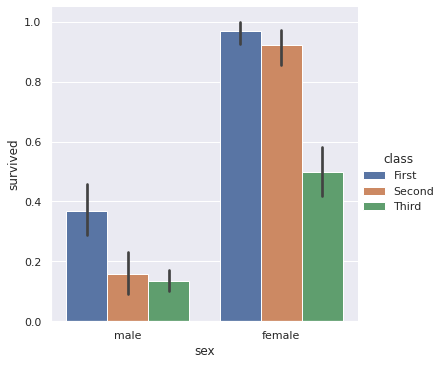

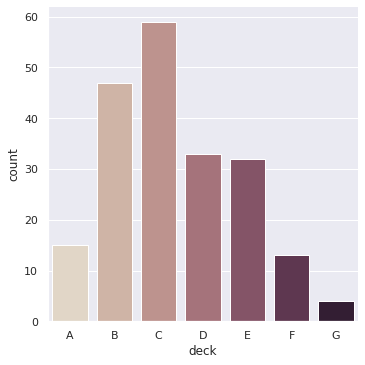

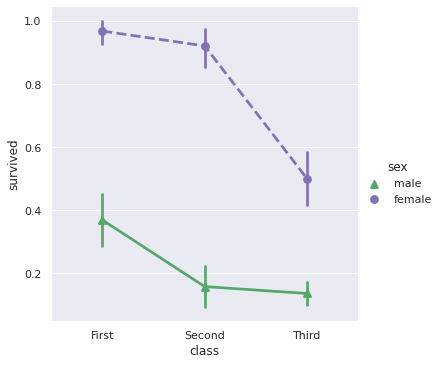

In [ ]:
# 3.2.3. Statistical Estimation within categories: barplot, countplot, pointplot

titanic = sns.load_dataset("titanic")

# bar
sns.catplot(x="sex", y="survived", hue="class", kind="bar", data=titanic)

# 그냥 count를 세고 싶다면
sns.catplot(x="deck", kind="count", palette="ch:.25", data=titanic)

# point
sns.catplot(x="class", y="survived", hue="sex", data=titanic,
               palette={"male": "g", "female": "m"}, kind="point",
               markers=["^", "o"], linestyles=["-", "--"])

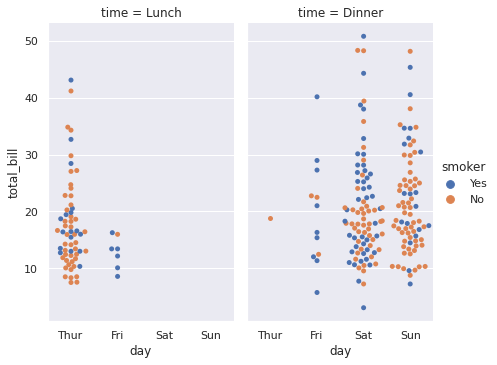

In [ ]:
# 3.2.4. Showing multiple relationships with facets
# catplot 역시 relplot 처럼 col argument를 사용해 여러 그래프를 그릴 수 있음
sns.catplot(x="day", y="total_bill", hue="smoker",
            col="time", aspect=0.6, kind="swarm", data=tips)

#3.3. Visualizing the distribution of a dataset

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2056: FutureWarning: The `axis` variable is no longer used and will be removed. Instead, assign variables directly to `x` or `y`.
  warnings.warn(msg, FutureWarning)


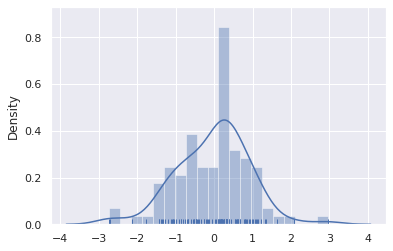

In [ ]:
# 3.2.1. 일변량 분포
x = np.random.normal(size=100)
sns.distplot(x, hist=True, bins=20, kde=True, rug=True)

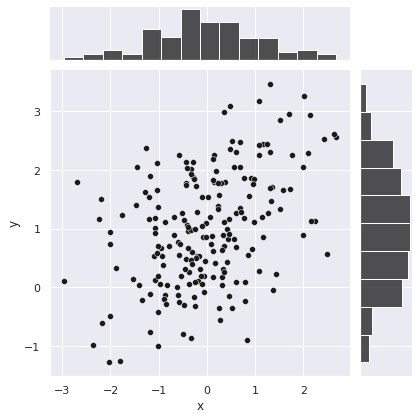

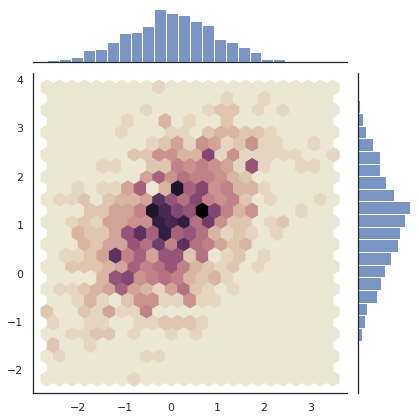

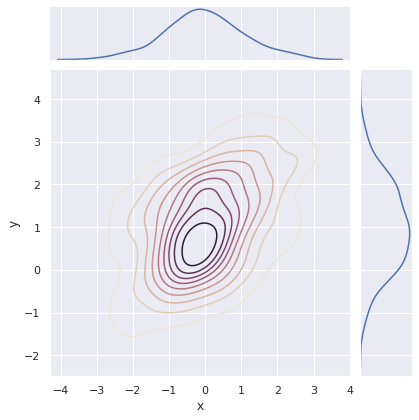

In [ ]:
# 3.2.2. 이변량 분포
# Prep
mean, cov = [0, 1], [(1, .5), (.5, 1)]
data = np.random.multivariate_normal(mean, cov, 200)
df = pd.DataFrame(data, columns=["x", "y"])
x, y = np.random.multivariate_normal(mean, cov, 1000).T
cmap = sns.cubehelix_palette(as_cmap=True, start=0, rot=0.5, dark=0, light=0.9)

# Scatter plot
sns.jointplot(x="x", y="y", data=df, color='k')

# Hexbin plot
with sns.axes_style("white"):
    sns.jointplot(x=x, y=y, kind="hex", cmap=cmap)

# Kernel Density Estimation
sns.jointplot(x="x", y="y", data=df, kind="kde", cmap=cmap)

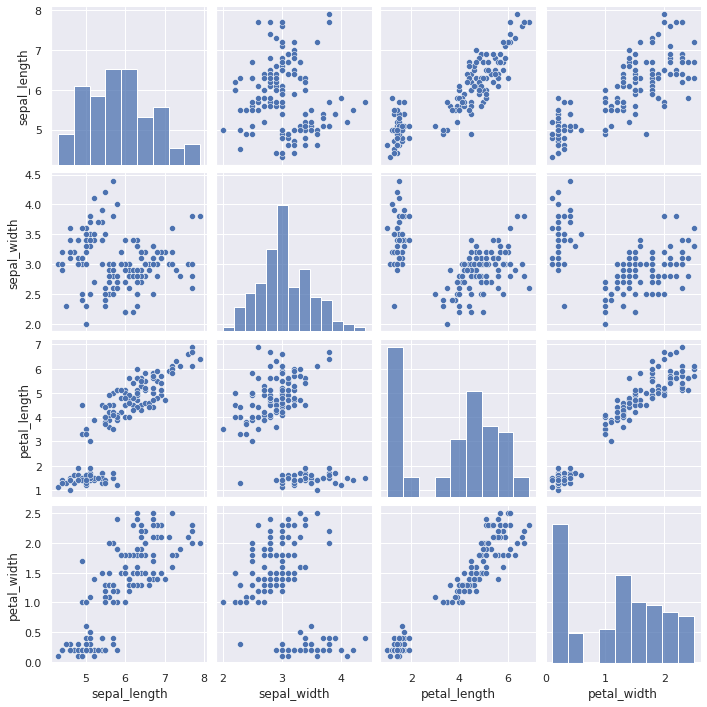

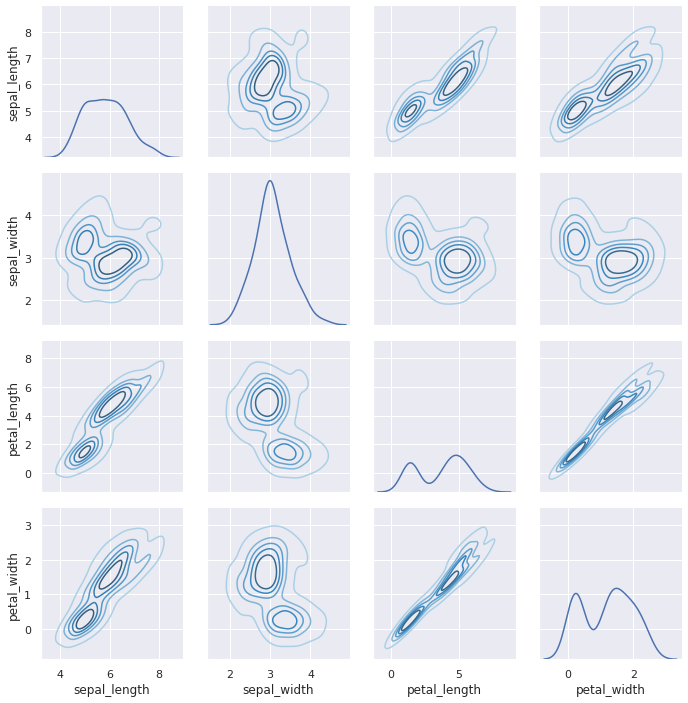

In [ ]:
# 3.2.3. Pairwise 관계 시각화
iris = sns.load_dataset('iris')
sns.pairplot(iris)

g = sns.PairGrid(iris)
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot, cmap="Blues_d", n_levels=6);

# statsmodel

패키지 로드

In [5]:
import statsmodels.api as sm

import pandas

from patsy import dmatrices

In [6]:
df = sm.datasets.get_rdataset("Guerry", "HistData").data

In [7]:
vars = ['Department', 'Lottery', 'Literacy', 'Wealth', 'Region']
df = df[vars]
df[-5:]

,Department,Lottery,Literacy,Wealth,Region
81,Vienne,40,25,68,W
82,Haute-Vienne,55,13,67,C
83,Vosges,14,62,82,E
84,Yonne,51,47,30,C
85,Corse,83,49,37,NaN


In [8]:
df = df.dropna()
df[-5:]

,Department,Lottery,Literacy,Wealth,Region
80,Vendee,68,28,56,W
81,Vienne,40,25,68,W
82,Haute-Vienne,55,13,67,C
83,Vosges,14,62,82,E
84,Yonne,51,47,30,C


In [9]:
y, X = dmatrices('Lottery ~ Literacy + Wealth + Region', data=df, return_type='dataframe')

In [10]:
y[:3]

,Lottery
0,41.0
1,38.0
2,66.0


In [11]:
X[:3]

,Intercept,Region[T.E],Region[T.N],Region[T.S],Region[T.W],Literacy,Wealth
0,1.0,1.0,0.0,0.0,0.0,37.0,73.0
1,1.0,0.0,1.0,0.0,0.0,51.0,22.0
2,1.0,0.0,0.0,0.0,0.0,13.0,61.0


Model fit and summary

In [13]:
mod = sm.OLS(y, X)    # Describe model
res = mod.fit()       # Fit model
print(res.summary())   # Summarize model

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     6.636
Date:                Fri, 26 Feb 2021   Prob (F-statistic):           1.07e-05
Time:                        14:09:33   Log-Likelihood:                -375.30
No. Observations:                  85   AIC:                             764.6
Df Residuals:                      78   BIC:                             781.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      38.6517      9.456      4.087      

In [14]:
res.params

Intercept      38.651655
Region[T.E]   -15.427785
Region[T.N]   -10.016961
Region[T.S]    -4.548257
Region[T.W]   -10.091276
Literacy       -0.185819
Wealth          0.451475
dtype: float64

In [15]:
res.rsquared

0.3379508691928822

Diagnostics and specification tests

In [16]:
sm.stats.linear_rainbow(res)

(0.8472339976156905, 0.6997965543621665)

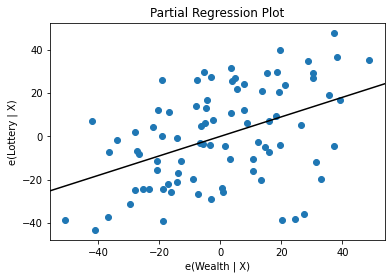

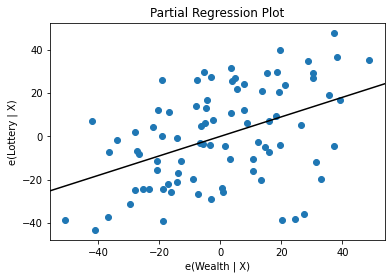

In [17]:
sm.graphics.plot_partregress('Lottery', 'Wealth', ['Region', 'Literacy'],data=df, obs_labels=False)

statsmodels를 사용하여 선형 회귀 분석을 수행하는 간단한 예를 보인다.

In [3]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

import numpy as np

# 데이터 로드
dat = sm.datasets.get_rdataset("Guerry", "HistData").data
dat.tail()

,dept,Region,Department,Crime_pers,Crime_prop,Literacy,Donations,Infants,Suicides,MainCity,Wealth,Commerce,Clergy,Crime_parents,Infanticide,Donation_clergy,Lottery,Desertion,Instruction,Prostitutes,Distance,Area,Pop1831
81,86,W,Vienne,15010,4710,25,8922,35224,21851,2:Med,68,43,71,20,1,44,40,38,65,18,170.523,6990,282.73
82,87,C,Haute-Vienne,16256,6402,13,13817,19940,33497,2:Med,67,63,76,68,6,78,55,11,84,7,198.874,5520,285.13
83,88,E,Vosges,18835,9044,62,4040,14978,33029,2:Med,82,42,51,58,34,5,14,85,11,43,174.477,5874,397.99
84,89,C,Yonne,18006,6516,47,4276,16616,12789,2:Med,30,15,55,32,22,35,51,66,27,272,81.797,7427,352.49
85,200,NaN,Corse,2199,4589,49,37015,24743,37016,2:Med,37,83,1,81,2,84,83,9,25,1,539.213,8680,195.41


In [4]:
results = smf.ols('Lottery ~ Literacy + np.log(Pop1831)', data=dat).fit()

# 결과 출력
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                Lottery   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     22.20
Date:                Fri, 26 Feb 2021   Prob (F-statistic):           1.90e-08
Time:                        14:02:22   Log-Likelihood:                -379.82
No. Observations:                  86   AIC:                             765.6
Df Residuals:                      83   BIC:                             773.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         246.4341     35.233     